# 📊 Hypothesis Testing – Deep Conceptual Explanation
### Using Titanic Dataset (Beginner to Industry Level)

This notebook explains:
- What hypothesis really means
- What Null & Alternative hypotheses are
- What p-value means (intuitively + technically)
- What t-value means
- Significance level (0.05)
- Type I & Type II errors
- Effect size
- How companies use this in real life

Everything explained step-by-step using Titanic dataset.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## Step 1️⃣ Load Titanic Dataset

In [5]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---
# 1️⃣ What is a Hypothesis?

A hypothesis is simply a statement we want to test using data.

In real life example:
'Female passengers survived more than male passengers.'

But we cannot just believe it by looking.
We must prove it statistically.

---
# 2️⃣ Null vs Alternative Hypothesis

## Null Hypothesis (H0)
This assumes NOTHING special is happening.
It assumes no difference.

For Titanic:
H0: Survival rate of males = females

## Alternative Hypothesis (H1)
This assumes there IS a difference.

H1: Survival rate of males ≠ females

We start by assuming H0 is true.
Then we try to find evidence against it.

## Step 2️⃣ Visualize Survival by Gender

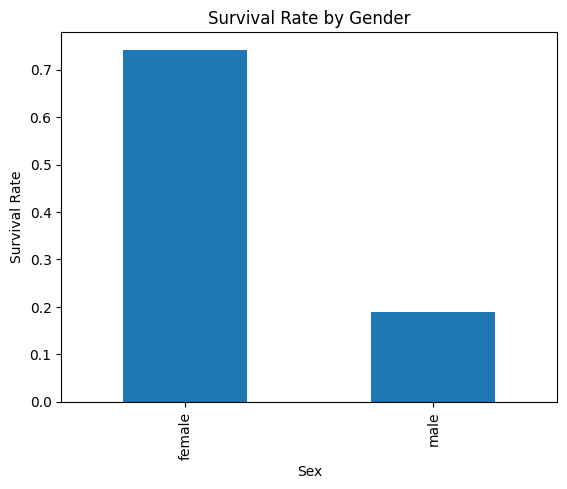

In [6]:
df.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.show()

---
# 3️⃣ What is a t-test?

A t-test compares the average (mean) of two groups.

In Titanic:
We compare:
- Average survival of males
- Average survival of females

---
# What is t-value?

t-value measures how FAR the difference is from 0.
Larger absolute t-value → stronger evidence.

It is like a 'distance score'.

---
# What is p-value?

p-value tells us:
If H0 was true, what is the probability of seeing this extreme result?

Small p-value → Very unlikely under H0 → Reject H0
Large p-value → Could happen by chance → Keep H0

In [7]:
male = df[df['Sex'] == 'male']['Survived']
female = df[df['Sex'] == 'female']['Survived']

t_stat, p_value = stats.ttest_ind(male, female)
print('T-value:', t_stat)
print('P-value:', p_value)

T-value: -19.297816550123354
P-value: 1.4060661308802591e-69


---
# 4️⃣ What is Significance Level (0.05)?

0.05 means 5%.

We are saying:
'I am okay being wrong 5% of the time.'

If p-value < 0.05 → Reject H0
If p-value ≥ 0.05 → Do not reject H0

## Visual Understanding of 0.05 Region

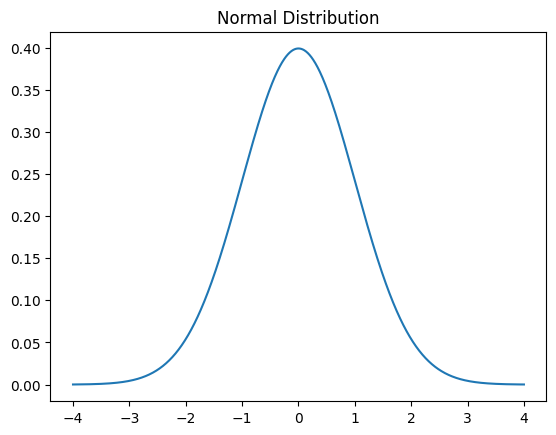

In [8]:
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

plt.plot(x, y)
plt.title('Normal Distribution')
plt.show()

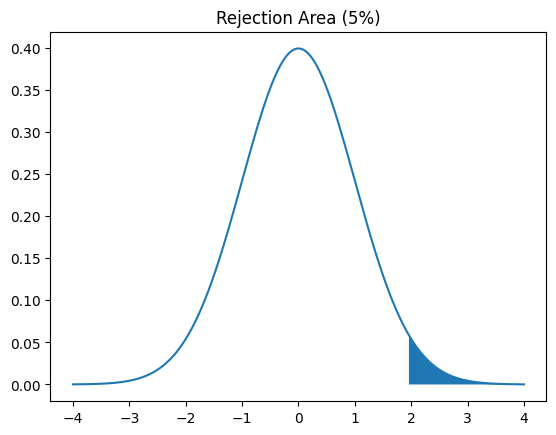

In [9]:
x2 = np.linspace(1.96, 4, 500)
y2 = stats.norm.pdf(x2)

plt.plot(np.linspace(-4,4,1000), stats.norm.pdf(np.linspace(-4,4,1000)))
plt.fill_between(x2, y2)
plt.title('Rejection Area (5%)')
plt.show()

---
# 5️⃣ Type I and Type II Errors

## Type I Error
Reject H0 when it is actually true.
False alarm.

## Type II Error
Do not reject H0 when it is false.
Missed detection.

0.05 controls Type I error.

---
# 6️⃣ Effect Size

Even if p-value is small, how big is the difference?
Effect size tells how strong the difference is.

In [10]:
effect_size = female.mean() - male.mean()
print('Difference in survival rate:', effect_size)

Difference in survival rate: 0.5531300709799203


---
# 7️⃣ Industry Meaning of Terms

## p-value
Probability of seeing this result if nothing changed.
Used in A/B testing.

## t-value
Signal strength of difference.

## Significance Level
Risk tolerance level of company.

## Effect Size
Business impact size.

Companies like Amazon, Netflix, Swiggy use this daily
to test new features before launching.